生成图像


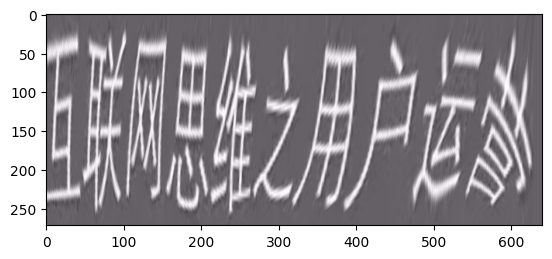

In [2]:
# pip install opencv-contrib-python==4.5.5.64 无需转opencv-python
import json
import matplotlib.pyplot as plt
import cv2, json
import numpy as np


def tps_cv2(source, img):
    """
    source: list [(x0, y0), (x1, y1), (x2, y2), ...]
    """
    if isinstance(source, list):
        source = np.array(source)

    tps = cv2.createThinPlateSplineShapeTransformer()

    source_cv2 = source.reshape(1, -1, 2)

    matches = list()
    for i in range(len(source_cv2[0])):
        matches.append(cv2.DMatch(i, i, 0))

    new_points = []
    N = len(source)    # 原图上轮廓点的个数 eg = 26
    N = N // 2
    h, w = img.shape[:2]
    dx = int(w / (N - 1))  # 将w分成N份，每份是dx
    # 这里产生的是上部分的点
    for i in range(N):
        new_points.append((dx * i, 2))

    # 这里产生的是下部分的点
    for i in range(N - 1, -1, -1):
        new_points.append((dx * i, h - 2))

    target_cv2 = np.array(new_points, np.int32)
    target_cv2 = target_cv2.reshape(1, -1, 2)

    tps.estimateTransformation(target_cv2, source_cv2, matches)
    new_img_cv2 = tps.warpImage(img)

    return new_img_cv2

source = [[217, 135], [302, 89], [419, 56], [589, 58], [716, 88],
          [815, 131], [789, 180], [697, 144], [578, 116], [426, 116],
          [320, 149], [245, 183]]

img = cv2.imread('wq_text/1.jpg')
json_path = r'wq_text/1.json'
with open(json_path,'r') as f:
    json_Data = json.load(f)
points_l1 = json_Data["shapes"][0]['points']



# img = cv2.polylines(img,[np.array(np.int0(points_l1))],isClosed=True,color=(0,0,255))
# cv2.imshow('t',img)
# cv2.waitKey()

new_img = tps_cv2(points_l1, img)
cv2.imwrite('res_tps_img.jpeg', new_img)
print('生成图像')
plt.imshow(new_img)
